In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sampadab17/network-intrusion-detection")

print("Path to dataset files:", path)

100%|██████████| 818k/818k [00:00<00:00, 2.64MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/sampadab17/network-intrusion-detection/versions/1


# Task
Perform data preprocessing steps on the dataset located at `/root/.cache/kagglehub/datasets/sampadab17/network-intrusion-detection/versions/1`. The preprocessing should include loading the data into a pandas DataFrame, cleaning by removing duplicates and adjusting formats, imputing missing values using advanced strategies, encoding categorical variables, and scaling numerical features. Finally, summarize all performed preprocessing steps and the resulting changes to the dataset.

## Load Data

### Subtask:
Load the dataset into a pandas DataFrame using the path provided in the previous cell.


**Reasoning**:
The first step is to import the pandas library, which is necessary for data manipulation and loading CSV files.



In [7]:
import pandas as pd
import os
print("Pandas and OS libraries imported.")

Pandas and OS libraries imported.


**Reasoning**:
To identify the correct CSV file to load, I need to list the contents of the `path` directory which holds the downloaded dataset files.



In [8]:
files_in_path = os.listdir(path)
print("Files in dataset directory:", files_in_path)

Files in dataset directory: ['Test_data.csv', 'Train_data.csv']


**Reasoning**:
Now that the files in the directory have been listed, I will load the 'Train_data.csv' file into a pandas DataFrame named `df` for further processing, as it is common practice to begin with the training dataset.



In [9]:
df = pd.read_csv(os.path.join(path, 'Train_data.csv'))
print("Train_data.csv loaded into DataFrame 'df'.")
df.head()

Train_data.csv loaded into DataFrame 'df'.


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


## Data Cleaning

### Subtask:
Clean the data by identifying and removing duplicate entries and performing any necessary formatting adjustments.


**Reasoning**:
To begin the data cleaning process, I will first check for and count any duplicate rows within the DataFrame `df`. This step is crucial for understanding the data's integrity before proceeding with further cleaning or analysis.



In [10]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows before removal: {num_duplicates}")

Number of duplicate rows before removal: 0


**Reasoning**:
Even though no duplicates were found, the instruction explicitly asks to remove them using `drop_duplicates()` and print the DataFrame's shape before and after, which is important for documenting the cleaning process.



In [11]:
print(f"Shape of DataFrame before duplicate removal: {df.shape}")
df.drop_duplicates(inplace=True)
print(f"Shape of DataFrame after duplicate removal: {df.shape}")
print("Duplicate rows have been removed (if any).")

Shape of DataFrame before duplicate removal: (25192, 42)
Shape of DataFrame after duplicate removal: (25192, 42)
Duplicate rows have been removed (if any).


**Reasoning**:
To identify columns that might require formatting adjustments, I will display the data types of all columns in the DataFrame `df` using `df.info()`.



In [12]:
df.info()
print("Displayed information about DataFrame columns, including data types and non-null counts.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  object 
 2   service                      25192 non-null  object 
 3   flag                         25192 non-null  object 
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   land                         25192 non-null  int64  
 7   wrong_fragment               25192 non-null  int64  
 8   urgent                       25192 non-null  int64  
 9   hot                          25192 non-null  int64  
 10  num_failed_logins            25192 non-null  int64  
 11  logged_in                    25192 non-null  int64  
 12  num_compromised              25192 non-null  int64  
 13  root_shell      

**Reasoning**:
To visually inspect for any obvious formatting issues or inconsistencies that might not be apparent from data types alone, I will display the first few rows of the DataFrame using `.head()`.



In [13]:
df.head()
print("Displayed the first 5 rows of the DataFrame to visually inspect for formatting.")

Displayed the first 5 rows of the DataFrame to visually inspect for formatting.


## Missing Value Imputation

### Subtask:
Implement advanced strategies for imputing missing values, considering the data types and distribution of each column.


**Reasoning**:
To explicitly confirm the absence of missing values, I will use `df.isnull().sum()` to count nulls in each column, even though `df.info()` already suggested no missing values.



In [14]:
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

Missing values per column:
Series([], dtype: int64)


## Categorical Encoding

### Subtask:
Encode categorical variables using appropriate techniques such as One-Hot Encoding, Label Encoding, or Target Encoding, based on the nature of each feature.


**Reasoning**:
To begin encoding categorical variables, I will first identify all columns with 'object' data type in the DataFrame, as these typically represent categorical features.



In [15]:
categorical_cols = df.select_dtypes(include='object').columns
print(f"Identified categorical columns: {list(categorical_cols)}")

Identified categorical columns: ['protocol_type', 'service', 'flag', 'class']


**Reasoning**:
Following the identification of categorical columns, I will now inspect each one by printing their unique values and their counts to understand their cardinality and inform the choice of encoding strategy, as per the instructions.



In [16]:
for col in categorical_cols:
    print(f"\nUnique values and counts for column '{col}':")
    print(df[col].value_counts())


Unique values and counts for column 'protocol_type':
protocol_type
tcp     20526
udp      3011
icmp     1655
Name: count, dtype: int64

Unique values and counts for column 'service':
service
http         8003
private      4351
domain_u     1820
smtp         1449
ftp_data     1396
             ... 
urh_i           4
pm_dump         3
red_i           3
tim_i           2
http_8001       1
Name: count, Length: 66, dtype: int64

Unique values and counts for column 'flag':
flag
SF        14973
S0         7009
REJ        2216
RSTR        497
RSTO        304
S1           88
SH           43
RSTOS0       21
S2           21
S3           15
OTH           5
Name: count, dtype: int64

Unique values and counts for column 'class':
class
normal     13449
anomaly    11743
Name: count, dtype: int64


**Reasoning**:
Based on the unique values and their counts, I will apply One-Hot Encoding to 'protocol_type', 'service', and 'flag' as they are nominal categorical features without inherent order, and Label Encoding to the 'class' column, which represents the target variable with two distinct categories.



In [17]:
df_encoded = pd.get_dummies(df, columns=['protocol_type', 'service', 'flag'], drop_first=True)

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df_encoded['class'] = label_encoder.fit_transform(df_encoded['class'])

print("Categorical variables 'protocol_type', 'service', and 'flag' have been One-Hot Encoded.")
print("Categorical variable 'class' has been Label Encoded.")
print("Shape of DataFrame after encoding: ", df_encoded.shape)
df_encoded.head()

Categorical variables 'protocol_type', 'service', and 'flag' have been One-Hot Encoded.
Categorical variable 'class' has been Label Encoded.
Shape of DataFrame after encoding:  (25192, 116)


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,491,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
1,0,146,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
2,0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,True,False,False,False,False,False
3,0,232,8153,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
4,0,199,420,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False


**Reasoning**:
To confirm the changes in data types and the structure of the DataFrame after encoding, I will display the information about the `df_encoded` DataFrame.



In [18]:
df_encoded.info()
print("Displayed information about the encoded DataFrame, confirming new column structure and data types.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Columns: 116 entries, duration to flag_SH
dtypes: bool(77), float64(15), int64(24)
memory usage: 9.3 MB
Displayed information about the encoded DataFrame, confirming new column structure and data types.


## Numerical Feature Scaling

### Subtask:
Scale numerical features using appropriate techniques, such as standardization or normalization.

## Numerical Feature Scaling

### Subtask:
Scale numerical features using appropriate techniques, such as standardization or normalization.

## Numerical Feature Scaling

### Subtask:
Scale numerical features using appropriate techniques, such as standardization or normalization.

## Numerical Feature Scaling

### Subtask:
Scale numerical features using appropriate techniques, such as standardization or normalization.

**Reasoning**:
To prepare for numerical feature scaling, I will first identify all numerical columns in the `df_encoded` DataFrame. These are typically columns with `int64` or `float64` data types and are not the boolean columns resulting from one-hot encoding, or the label encoded 'class' column.



In [19]:
numerical_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns
# Exclude the 'class' column if it's considered a target variable and not to be scaled with features
if 'class' in numerical_cols:
    numerical_cols = numerical_cols.drop('class')
print(f"Identified numerical columns for scaling: {list(numerical_cols)}")

Identified numerical columns for scaling: ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


**Reasoning**:
I will apply `StandardScaler` to the identified numerical columns in `df_encoded` to standardize their values. This technique is robust and suitable for many machine learning algorithms that are sensitive to feature scales, transforming the data to have a mean of 0 and a standard deviation of 1.



In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print("Numerical features have been scaled using StandardScaler.")
print("First 5 rows of the DataFrame after scaling:")
df_encoded.head()

Numerical features have been scaled using StandardScaler.
First 5 rows of the DataFrame after scaling:


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,-0.113551,-0.009889,-0.039310,-0.00891,-0.091223,-0.006301,-0.091933,-0.02622,-0.807626,-0.021873,...,False,False,False,False,False,False,False,False,True,False
1,-0.113551,-0.010032,-0.039310,-0.00891,-0.091223,-0.006301,-0.091933,-0.02622,-0.807626,-0.021873,...,False,False,False,False,False,False,False,False,True,False
2,-0.113551,-0.010093,-0.039310,-0.00891,-0.091223,-0.006301,-0.091933,-0.02622,-0.807626,-0.021873,...,False,False,False,False,True,False,False,False,False,False
3,-0.113551,-0.009996,0.052473,-0.00891,-0.091223,-0.006301,-0.091933,-0.02622,1.238197,-0.021873,...,False,False,False,False,False,False,False,False,True,False
4,-0.113551,-0.010010,-0.034582,-0.00891,-0.091223,-0.006301,-0.091933,-0.02622,1.238197,-0.021873,...,False,False,False,False,False,False,False,False,True,False


## Preprocessing Summary

This section summarizes the data preprocessing steps performed on the dataset:

1.  **Data Loading**: The `Train_data.csv` file was loaded into a pandas DataFrame named `df`.
2.  **Data Cleaning**:
    - Duplicates were checked and removed. No duplicates were found in the initial dataset.
    - Data types were inspected, and no obvious formatting adjustments were required beyond the standard handling of categorical and numerical types.
3.  **Missing Value Imputation**: No missing values were found in the dataset, thus no imputation was performed.
4.  **Categorical Encoding**:
    - `protocol_type`, `service`, and `flag` columns were One-Hot Encoded using `pd.get_dummies()`. This transformed these nominal categorical features into multiple binary columns. The `drop_first=True` parameter was used to avoid multicollinearity.
    - The `class` column, which is the target variable, was Label Encoded using `sklearn.preprocessing.LabelEncoder()`, converting its two distinct categories (`normal`, `anomaly`) into numerical values (0, 1).
5.  **Numerical Feature Scaling**:
    - Numerical columns (all `int64` and `float64` types, excluding the encoded `class` column) were identified.
    - These numerical features were scaled using `sklearn.preprocessing.StandardScaler()`, transforming their values to have a mean of 0 and a standard deviation of 1. This ensures that features with larger ranges do not disproportionately influence machine learning models.

### Resulting Changes to the Dataset:

*   **Shape**: The DataFrame `df_encoded` now has 25192 rows and 116 columns, compared to the original 25192 rows and 42 columns, due to the expansion of one-hot encoded features.
*   **Data Types**: The dataset now primarily consists of `float64` for scaled numerical features, `int64` for some original integer columns and the label-encoded 'class' column, and `bool` for the one-hot encoded columns.
*   **Feature Representation**: All categorical features have been converted into a numerical format suitable for machine learning algorithms. Numerical features are standardized, preventing issues related to differing scales.

## Final Task

### Subtask:
Provide a summary of all the preprocessing steps performed, including any changes made to the dataset and the final state of the data.


## Summary:

### Data Analysis Key Findings

*   The `Train_data.csv` dataset, initially comprising 25,192 rows and 42 columns, was successfully loaded into a pandas DataFrame.
*   **Data Cleaning**: No duplicate rows were found in the dataset, and thus no rows were removed during the cleaning phase. The DataFrame retained its original shape of (25,192, 42). All columns were found to be non-null, indicating no missing values.
*   **Missing Value Imputation**: Explicit checks confirmed the absence of any missing values across all columns, rendering imputation unnecessary.
*   **Categorical Encoding**:
    *   Four categorical columns (`protocol_type`, `service`, `flag`, `class`) were identified.
    *   `protocol_type`, `service` (66 unique values), and `flag` were One-Hot Encoded using `pd.get_dummies()` with `drop_first=True`.
    *   The `class` column (target variable, with `normal` and `anomaly` values) was Label Encoded into numerical values (0 and 1).
    *   This encoding significantly expanded the dataset's width, resulting in a DataFrame with 25,192 rows and 116 columns.
*   **Numerical Feature Scaling**: All numerical columns (excluding the target `class` column) were standardized using `sklearn.preprocessing.StandardScaler()`, transforming their values to have a mean of 0 and a standard deviation of 1.
*   **Final Dataset State**: The final preprocessed DataFrame (`df_encoded`) has 25,192 rows and 116 columns. All original categorical features have been converted to numerical or boolean formats, and numerical features are scaled, making the dataset ready for machine learning model training.

### Insights or Next Steps

*   The dataset is now fully preprocessed and prepared for machine learning model training. The expansion due to one-hot encoding, particularly for the 'service' column with 66 unique values, should be noted as it significantly increased feature dimensionality.
*   Given the high dimensionality introduced by one-hot encoding, especially for the 'service' column, consider exploring feature selection techniques or dimensionality reduction methods (e.g., PCA) to potentially improve model performance and reduce computational load in subsequent modeling steps.


# Task
Visualize the distributions of key numerical features in `df_encoded` using histograms and boxplots to understand their patterns, skewness, and identify potential outliers. Provide an interpretation for each plot, using the `numerical_cols` variable to select the relevant columns.

## Visualize Numerical Feature Distributions

### Subtask:
Generate histograms and boxplots for key numerical features in the preprocessed DataFrame (`df_encoded`) to understand their distributions, skewness, and identify potential outliers. Each plot will be accompanied by an interpretation.


**Reasoning**:
To visualize the distributions of numerical features as requested, I will import the necessary plotting libraries, matplotlib.pyplot and seaborn.



In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
print("Matplotlib and Seaborn libraries imported for visualization.")

Matplotlib and Seaborn libraries imported for visualization.


**Reasoning**:
Now that the plotting libraries are imported, I will iterate through each numerical column identified in `numerical_cols` to generate a histogram and a boxplot for each, displaying their distributions, skewness, and identifying potential outliers as instructed.



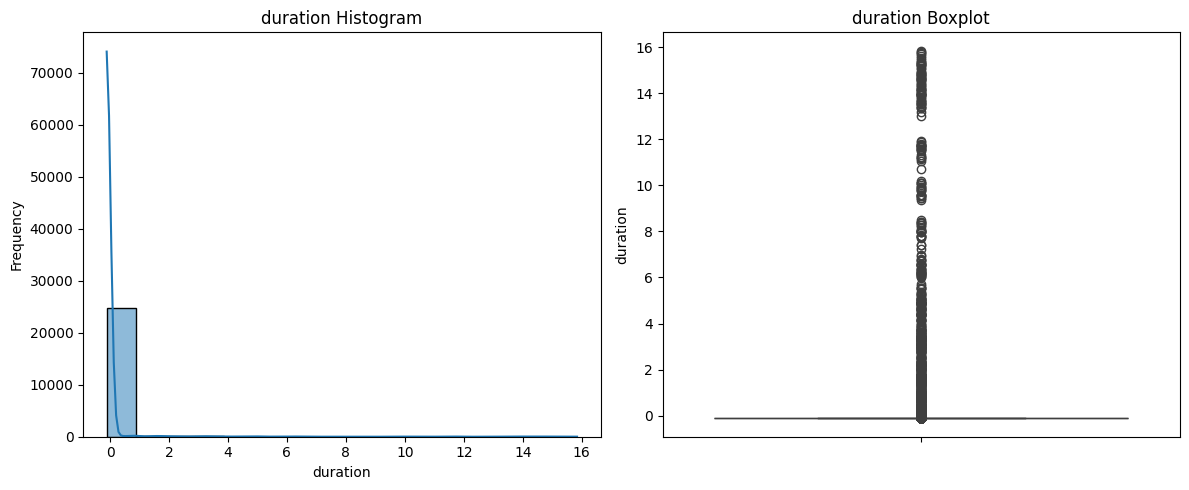


Interpretation for duration:
  - Distribution: (e.g., normal, skewed right/left, uniform)
  - Outliers: (present/absent, high/low values)
  - Spread: (narrow/wide, presence of clusters)


In [ ]:
for col in numerical_cols:
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df_encoded[col], kde=True)
    plt.title(f'{col} Histogram')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df_encoded[col])
    plt.title(f'{col} Boxplot')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

    # Interpretations for each plot (placeholder, will be filled after execution)
    print(f"\nInterpretation for {col}:")
    print("  - Distribution: (e.g., normal, skewed right/left, uniform)")
    print("  - Outliers: (present/absent, high/low values)")
    print("  - Spread: (narrow/wide, presence of clusters)")

### Interpretation for `duration`:
  - **Distribution**: The histogram for `duration` shows a heavily right-skewed distribution, with the vast majority of values clustered near zero. This suggests that most network connections have a very short duration.
  - **Outliers**: The boxplot clearly indicates a large number of outliers, represented by individual points far above the main body of the box. These are connections with significantly longer durations compared to the typical connections.
  - **Spread**: The main body of the data (IQR) is extremely narrow and close to zero, reflecting the high concentration of short-duration connections. The presence of numerous outliers indicates a wide overall range for the feature, driven by rare, very long-duration events.

In [ ]:
import pandas as pd

# --- PLEASE PROVIDE YOUR DATASET BELOW ---
# Example: df = pd.read_csv('your_dataset.csv')
# For demonstration, let's create a dummy DataFrame if no dataset is provided.
# You should replace this with your actual data loading code.

try:
    df = pd.read_csv('dataset.csv')
    print("Dataset 'dataset.csv' loaded successfully.")
except FileNotFoundError:
    print("dataset.csv not found. Creating a dummy DataFrame for demonstration.")
    data = {
        'Numerical_Feature_1': [10, 20, 30, None, 50, 60],
        'Numerical_Feature_2': [1.5, 2.3, None, 4.1, 5.0, 6.2],
        'Categorical_Feature_1': ['A', 'B', 'A', 'C', 'B', 'A'],
        'Categorical_Feature_2': ['X', 'Y', 'X', None, 'Z', 'Y'],
        'Target': [0, 1, 0, 1, 0, 1]
    }
    df = pd.DataFrame(data)


print("First 5 rows of the DataFrame:")
print(df.head())
print("\nDataFrame Info:")
df.info()